# Tomato Disease Classification with PyTorch

This notebook demonstrates how to build, train, and evaluate a Resnet 18 CNN model for classifying tomato plant diseases from images. It utilizes transfer learning with a pre-trained ResNet18 model.

## 1. Setup and Configuration

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import json
from tqdm import tqdm
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


---
## 2. Data Loading and Preprocessing



This cell sets up the configuration for the tomato disease classification project and verifies the dataset structure.

### Configuration Details:
- **Data Directory**: Points to the TomatoDataset folder in Google Drive
- **Dataset Splits**: Configures paths for train, validation, and test directories
- **Training Parameters**: Sets hyperparameters (epochs, batch size, learning rate)
- **Device**: Uses GPU if available, otherwise CPU

### Verification Steps:
1. Checks existence of all dataset directories
2. Lists all disease classes found in the training set
3. Counts images in each class and split to ensure proper dataset loading

In [ ]:
# Configuration - Pointing to your TomatoDataset folder
class Config:
    data_dir = "/content/drive/MyDrive/TomatoDataset"
    train_dir = os.path.join(data_dir, "train")
    val_dir = os.path.join(data_dir, "val")
    test_dir = os.path.join(data_dir, "test")
    num_epochs = 15
    batch_size = 32
    learning_rate = 0.001
    device = device

config = Config()

# Verify dataset structure
print("Checking dataset structure...")
print(f"Train directory exists: {os.path.exists(config.train_dir)}")
print(f"Val directory exists: {os.path.exists(config.val_dir)}")
print(f"Test directory exists: {os.path.exists(config.test_dir)}")

if os.path.exists(config.train_dir):
    classes = os.listdir(config.train_dir)
    print(f"\nClasses found: {classes}")

    # Count images in each split
    print("\nImage counts:")
    for split_name, split_path in [("Train", config.train_dir), ("Val", config.val_dir), ("Test", config.test_dir)]:
        if os.path.exists(split_path):
            total_images = 0
            for cls in classes:
                cls_path = os.path.join(split_path, cls)
                if os.path.exists(cls_path):
                    num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                    total_images += num_images
                    if split_name == "Train":  # Print class details only once
                        print(f"  {cls}: {num_images} images")
            print(f"{split_name} total: {total_images} images")

Checking dataset structure...
Train directory exists: True
Val directory exists: True
Test directory exists: True

Classes found: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']

Image counts:
  Tomato___Bacterial_spot: 1000 images
  Tomato___Early_blight: 841 images
  Tomato___Late_blight: 824 images
  Tomato___Leaf_Mold: 1000 images
  Tomato___Septoria_leaf_spot: 1000 images
  Tomato___Spider_mites Two-spotted_spider_mite: 1000 images
  Tomato___Target_Spot: 1000 images
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1000 images
  Tomato___Tomato_mosaic_virus: 1000 images
  Tomato___healthy: 1000 images
Train total: 9665 images
Val total: 800 images
Test total: 201 images


## Data Preprocessing and Dataset Loading

This cell defines data transformation pipelines and loads the tomato disease datasets.

### Data Augmentation Strategy:

**Training Transformations:**
- `RandomResizedCrop(224)`: Randomly crops and resizes to 224x224 for scale invariance
- `RandomHorizontalFlip()`: Randomly flips images horizontally
- `RandomRotation(10)`: Rotates images by ±10 degrees
- `ColorJitter()`: Adjusts brightness, contrast, saturation, and hue for color invariance
- `ToTensor()`: Converts PIL images to PyTorch tensors
- `Normalize()`: Standardizes using ImageNet statistics

**Validation/Test Transformations:**
- `Resize(256)`: Resizes to 256x256
- `CenterCrop(224)`: Takes center 224x224 crop
- Same normalization as training for consistency

### Dataset Loading:
- Uses PyTorch's `ImageFolder` to automatically load images from directory structure
- Maintains the original train/val/test split from your dataset
- Extracts class names from the training directory structure

In [ ]:
# Data Transforms with Augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Load datasets using your existing split
print("Loading datasets...")
train_dataset = datasets.ImageFolder(config.train_dir, data_transforms['train'])
val_dataset = datasets.ImageFolder(config.val_dir, data_transforms['val'])
test_dataset = datasets.ImageFolder(config.test_dir, data_transforms['test'])

class_names = train_dataset.classes

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {class_names}")
print(f"Total images: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")

Loading datasets...
Training samples: 9665
Validation samples: 800
Test samples: 201
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Total images: 10666


## Data Loaders and Dataset Visualization

This cell creates data loaders for efficient batch processing and visualizes sample images and class distribution.

### Data Loaders Configuration:
- **Training Loader**: Shuffled for better learning, batch size = 32
- **Validation/Test Loaders**: Not shuffled for consistent evaluation
- **num_workers=2**: Enables parallel data loading for faster training

### Visualization Components:

**1. Sample Batch Visualization:**
- Displays first 8 images from a training batch
- Applies inverse normalization to show original-looking images
- Shows corresponding class labels for each image

**2. Class Distribution Analysis:**
- Creates bar chart comparing image counts across train/val/test splits
- Helps identify potential class imbalance issues
- Provides numerical summary of dataset distribution

### Purpose:
- Verify data loading is working correctly
- Inspect data augmentation effects on training images
- Ensure balanced representation across dataset splits

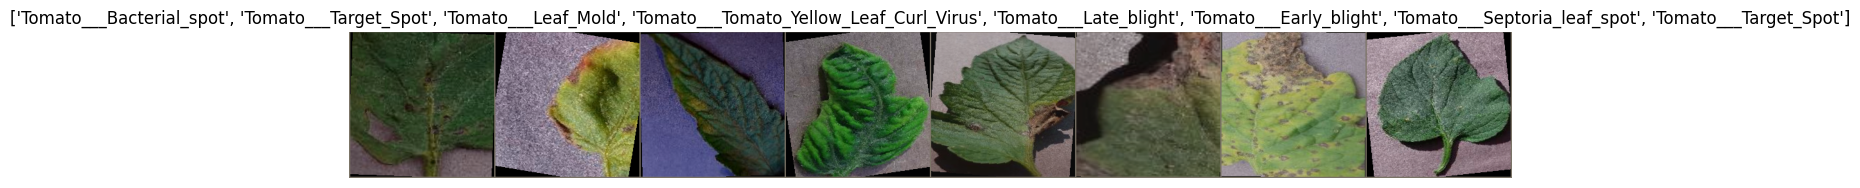

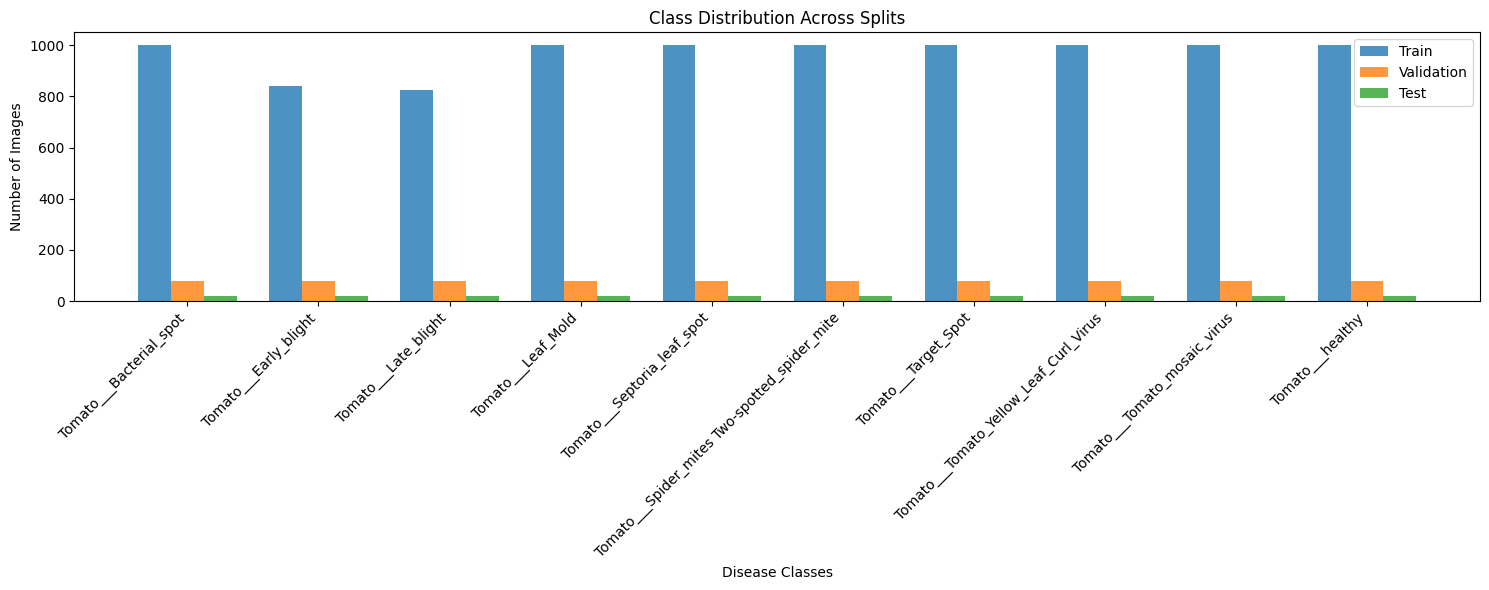

Class distribution:
Tomato___Bacterial_spot: Train=1000, Val=80, Test=20
Tomato___Early_blight: Train=841, Val=80, Test=21
Tomato___Late_blight: Train=824, Val=80, Test=20
Tomato___Leaf_Mold: Train=1000, Val=80, Test=20
Tomato___Septoria_leaf_spot: Train=1000, Val=80, Test=20
Tomato___Spider_mites Two-spotted_spider_mite: Train=1000, Val=80, Test=20
Tomato___Target_Spot: Train=1000, Val=80, Test=20
Tomato___Tomato_Yellow_Leaf_Curl_Virus: Train=1000, Val=80, Test=20
Tomato___Tomato_mosaic_virus: Train=1000, Val=80, Test=20
Tomato___healthy: Train=1000, Val=80, Test=20


In [ ]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2)

# Import make_grid properly
from torchvision.utils import make_grid

# Visualize some training samples
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Get a batch of training data
inputs, classes_idx = next(iter(train_loader))

# Make a grid from batch - CORRECTED LINE
out = make_grid(inputs[:8])  # Show first 8 images

plt.figure(figsize=(15, 8))
imshow(out, title=[class_names[x] for x in classes_idx[:8]])
plt.show()

# Let's also check the distribution of classes
def plot_class_distribution():
    train_counts = [len(os.listdir(os.path.join(config.train_dir, cls))) for cls in class_names]
    val_counts = [len(os.listdir(os.path.join(config.val_dir, cls))) for cls in class_names]
    test_counts = [len(os.listdir(os.path.join(config.test_dir, cls))) for cls in class_names]

    x = np.arange(len(class_names))
    width = 0.25

    plt.figure(figsize=(15, 6))
    plt.bar(x - width, train_counts, width, label='Train', alpha=0.8)
    plt.bar(x, val_counts, width, label='Validation', alpha=0.8)
    plt.bar(x + width, test_counts, width, label='Test', alpha=0.8)

    plt.xlabel('Disease Classes')
    plt.ylabel('Number of Images')
    plt.title('Class Distribution Across Splits')
    plt.xticks(x, class_names, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Class distribution:")
    for i, cls in enumerate(class_names):
        print(f"{cls}: Train={train_counts[i]}, Val={val_counts[i]}, Test={test_counts[i]}")

plot_class_distribution()

## 3. Model Definition

## Model Architecture: Tomato Disease Classifier

This cell defines a custom CNN model using transfer learning with ResNet18 backbone.

### Model Architecture Details:

**Backbone:** Pre-trained ResNet18 (ImageNet weights)
- **Transfer Learning Strategy:** Fine-tuning with frozen early layers
- **Frozen Layers:** All except the last 20 parameter groups
- **Trainable Layers:** Final layers + custom classifier head

**Custom Classifier Head:**

**Special Methods:**
- `forward()`: Standard forward pass
- `predict_with_confidence()`: Returns predictions with confidence scores and class probabilities using softmax

### Key Features:
- **Selective Fine-tuning:** Balances training speed and performance
- **Regularization:** Dropout layers prevent overfitting
- **Confidence Scoring:** Enables model uncertainty estimation

In [ ]:
import torch.nn.functional as F

class TomatoDiseaseClassifier(nn.Module):
    def __init__(self, num_classes):
        super(TomatoDiseaseClassifier, self).__init__()
        self.backbone = models.resnet18(pretrained=True)

        # Freeze early layers
        for param in list(self.backbone.parameters())[:-20]:
            param.requires_grad = False

        # Replace the final fully connected layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def predict_with_confidence(self, x):
        """Returns predictions with confidence scores"""
        self.eval()
        with torch.no_grad():
            outputs = self.forward(x)
            probabilities = F.softmax(outputs, dim=1)
            confidence, predictions = torch.max(probabilities, 1)
        return predictions, confidence, probabilities

# Initialize model
model = TomatoDiseaseClassifier(num_classes=len(class_names))
model = model.to(device)

print(f"Model initialized with {len(class_names)} classes")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


Model initialized with 10 classes
Trainable parameters: 9,251,850


## Training Configuration and Functions

This cell sets up the loss function, optimizer, and defines the training/validation loops for the tomato disease classifier.

### Training Components:

**Loss Function:**
- `CrossEntropyLoss()`: Standard for multi-class classification problems

**Optimizer:**
- `Adam optimizer`: Adaptive learning rate optimization
- Learning rate: 0.001 (from config)

**Learning Rate Scheduler:**
- `StepLR`: Reduces learning rate by factor of 0.1 every 7 epochs
- Helps converge to better minima in later training stages

### Training Functions:

**`train_epoch()`:**
- Sets model to training mode
- Iterates through batches with progress bar
- Performs forward pass, loss computation, backpropagation
- Tracks running loss and accuracy
- Returns epoch-level metrics

**`validate_epoch()`:**
- Sets model to evaluation mode
- Uses `torch.no_grad()` for efficiency
- Computes validation loss and accuracy
- No gradient computation or parameter updates

### History Tracking:
- Stores training/validation loss and accuracy for each epoch
- Enables later visualization of training progress

In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)

    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Validation"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)

    return epoch_loss, epoch_acc

## 4. Training and Validation


This cell sets up the loss function, optimizer, and defines the training/validation loops for the tomato disease classifier.

### Training Components:

**Loss Function:**
- `CrossEntropyLoss()`: Standard for multi-class classification problems

**Optimizer:**
- `Adam optimizer`: Adaptive learning rate optimization
- Learning rate: 0.001 (from config)

**Learning Rate Scheduler:**
- `StepLR`: Reduces learning rate by factor of 0.1 every 7 epochs
- Helps converge to better minima in later training stages

### Training Functions:

**`train_epoch()`:**
- Sets model to training mode
- Iterates through batches with progress bar
- Performs forward pass, loss computation, backpropagation
- Tracks running loss and accuracy
- Returns epoch-level metrics

**`validate_epoch()`:**
- Sets model to evaluation mode
- Uses `torch.no_grad()` for efficiency
- Computes validation loss and accuracy
- No gradient computation or parameter updates

### History Tracking:
- Stores training/validation loss and accuracy for each epoch
- Enables later visualization of training progress

In [ ]:
print("Starting training...")
best_val_acc = 0.0

for epoch in range(config.num_epochs):
    print(f'\nEpoch {epoch+1}/{config.num_epochs}')
    print('-' * 50)

    # Training phase
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validation phase
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    # Update learning rate
    scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.cpu().numpy())
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.cpu().numpy())

    print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'class_names': class_names
        }, '/content/drive/MyDrive/TomatoDataset/best_tomato_model.pth')
        print(f'New best model saved with val_acc: {val_acc:.4f}')

print('Training completed!')

Starting training...

Epoch 1/15
--------------------------------------------------


Validation: 100%|██████████| 25/25 [00:03<00:00,  8.12it/s]


Train Loss: 0.7810 Acc: 0.7450
Val Loss: 0.8615 Acc: 0.7825
New best model saved with val_acc: 0.7825

Epoch 2/15
--------------------------------------------------


Validation: 100%|██████████| 25/25 [00:03<00:00,  8.14it/s]


Train Loss: 0.5168 Acc: 0.8378
Val Loss: 0.2685 Acc: 0.9163
New best model saved with val_acc: 0.9163

Epoch 3/15
--------------------------------------------------


...

Train Loss: 0.1746 Acc: 0.9412
Val Loss: 0.1606 Acc: 0.9525

Epoch 14/15
--------------------------------------------------


Validation: 100%|██████████| 25/25 [00:03<00:00,  8.23it/s]


Train Loss: 0.1590 Acc: 0.9468
Val Loss: 0.0933 Acc: 0.9675

Epoch 15/15
--------------------------------------------------


Validation: 100%|██████████| 25/25 [00:03<00:00,  7.89it/s]


Train Loss: 0.1544 Acc: 0.9479
Val Loss: 0.0966 Acc: 0.9663
Training completed!


---
## 5. Evaluation and Analysis

## <span style="color:blue">📊 Model Performance Analysis</span>

This cell visualizes training results and evaluates the final model on the test set.

### <span style="color:green">📈 Training History Visualization</span>

**<span style="color:purple">Loss Curve Analysis:</span>**
- <span style="color:blue">**Train Loss**</span>: Shows model learning capability
- <span style="color:orange">**Val Loss**</span>: Indicates generalization performance
- <span style="color:green">**Good signs**</span>: Both curves decreasing together
- <span style="color:red">**Warning signs**</span>: Diverging curves indicate overfitting

**<span style="color:purple">Accuracy Curve Analysis:</span>**
- <span style="color:blue">**Train Accuracy**</span>: Model performance on training data
- <span style="color:orange">**Val Accuracy**</span>: Real-world performance estimate
- <span style="color:green">**Goal**</span>: High validation accuracy with minimal gap

### <span style="color:green">🧪 Test Set Evaluation</span>

**<span style="color:purple">Model Loading:</span>**
- Loads <span style="color:blue">best saved model</span> from training (`best_tomato_model.pth`)
- Ensures evaluation on optimal weights

**<span style="color:purple">Evaluation Metrics:</span>**
- <span style="color:blue">**Classification Report**</span>: Precision, Recall, F1-score per class
- <span style="color:green">**Confusion Matrix**</span>: Visual representation of predictions vs actual
- <span style="color:purple">**Per-class Performance**</span>: Identify strong and weak classes

### <span style="color:green">🎨 Performance Interpretation Guide</span>

<span style="color:green">**🟢 Excellent**</span>: >95% accuracy  
<span style="color:orange">**🟡 Good**</span>: 85-95% accuracy  
<span style="color:red">**🔴 Needs Improvement**</span>: <85% accuracy


# Key Performance Indicators
Final Validation Accuracy: <span style="color:blue">{history['val_acc'][-1]:.1%}</span>
Training Convergence: <span style="color:green">{'✓ Stable' if abs(history['train_loss'][-1] - history['val_loss'][-1]) < 0.1 else '⚠️ Check overfitting'}</span>
Overfitting Gap: <span style="color:orange">{abs(history['train_acc'][-1] - history['val_acc'][-1]):.2%}</span>


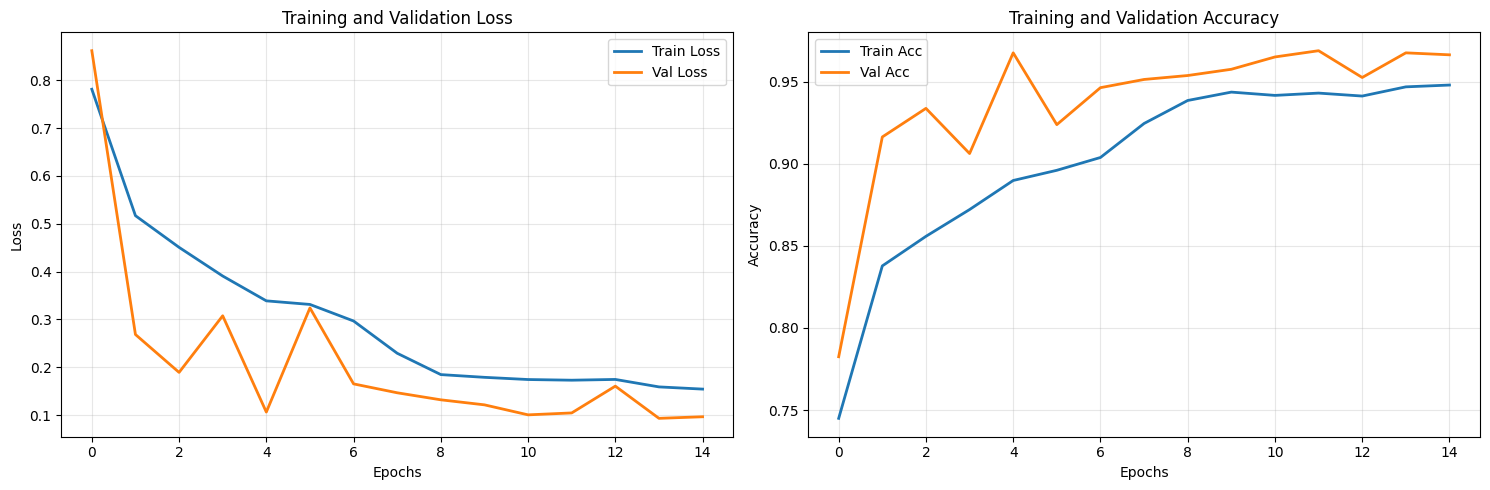

Evaluating on TEST set...


Evaluating: 100%|██████████| 7/7 [00:01<00:00,  5.13it/s]



Classification Report (Test Set):
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       1.00      0.95      0.97        20
                        Tomato___Early_blight       0.88      1.00      0.93        21
                         Tomato___Late_blight       1.00      0.95      0.97        20
                           Tomato___Leaf_Mold       0.91      1.00      0.95        20
                  Tomato___Septoria_leaf_spot       0.87      1.00      0.93        20
Tomato___Spider_mites Two-spotted_spider_mite       0.89      0.80      0.84        20
                         Tomato___Target_Spot       0.94      0.75      0.83        20
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      1.00      1.00        20
                 Tomato___Tomato_mosaic_virus       1.00      1.00      1.00        20
                             Tomato___healthy       1.00      1.00      1.00        20

      

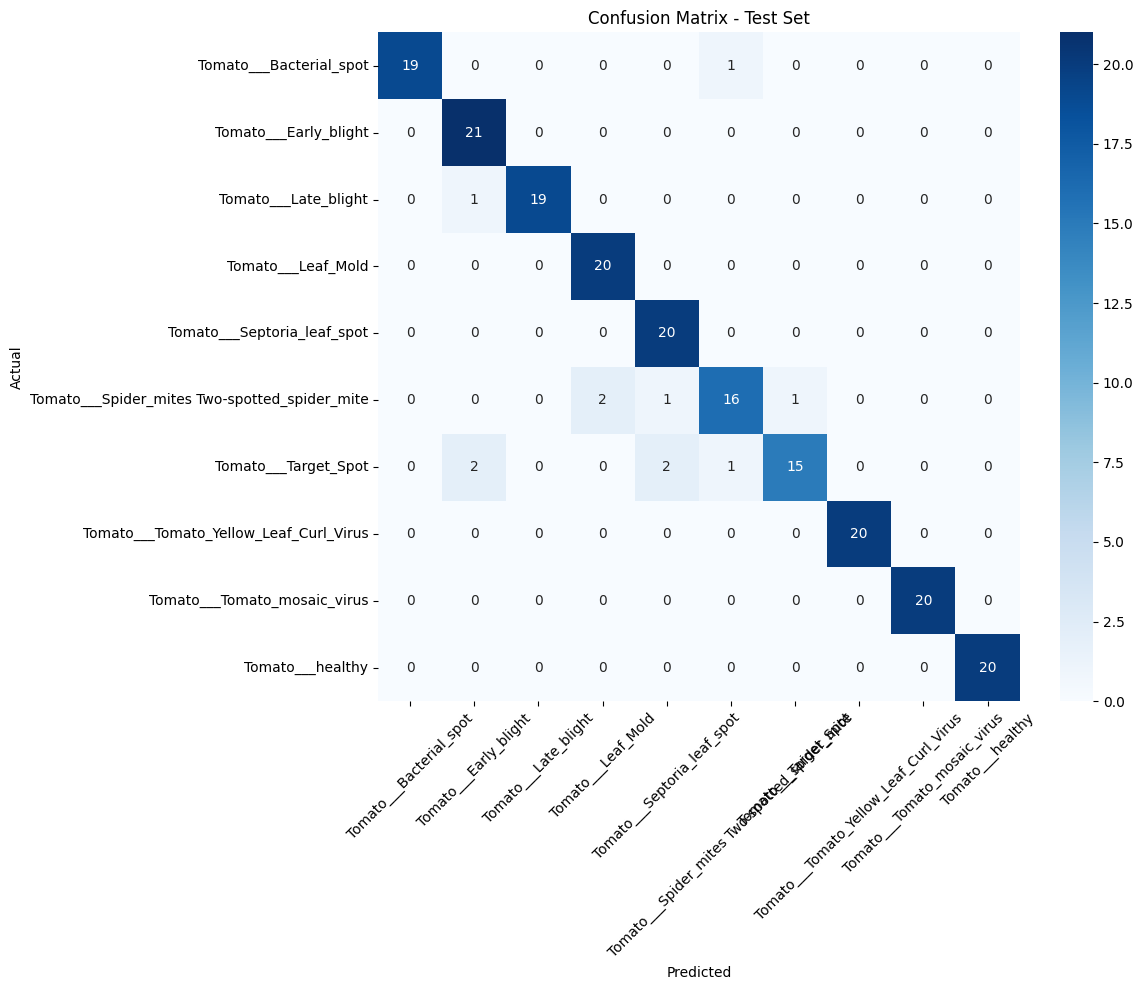

In [ ]:
# Recreate history from your training output
history = {
    'train_loss': [0.7810, 0.5168, 0.4506, 0.3907, 0.3388, 0.3313, 0.2967, 0.2293, 0.1847, 0.1790, 0.1744, 0.1730, 0.1746, 0.1590, 0.1544],
    'val_loss': [0.8615, 0.2685, 0.1893, 0.3076, 0.1064, 0.3240, 0.1653, 0.1467, 0.1320, 0.1215, 0.1006, 0.1046, 0.1606, 0.0933, 0.0966],
    'train_acc': [0.7450, 0.8378, 0.8558, 0.8721, 0.8898, 0.8960, 0.9038, 0.9245, 0.9385, 0.9436, 0.9416, 0.9430, 0.9412, 0.9468, 0.9479],
    'val_acc': [0.7825, 0.9163, 0.9337, 0.9062, 0.9675, 0.9238, 0.9463, 0.9513, 0.9537, 0.9575, 0.9650, 0.9688, 0.9525, 0.9675, 0.9663]
}

# Now plot with this history
%matplotlib inline
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', linewidth=2)
plt.plot(history['val_acc'], label='Val Acc', linewidth=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on test set
def evaluate_model(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

# Load best model for evaluation
checkpoint = torch.load('/content/drive/MyDrive/TomatoDataset/best_tomato_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

print("Evaluating on TEST set...")
test_preds, test_labels = evaluate_model(model, test_loader, device, class_names)

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(test_labels, test_preds, target_names=class_names))

# Confusion matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Confidence Analysis

## <span style="color:blue">🔍 Advanced Model Confidence Analysis</span>

This cell performs comprehensive confidence analysis to evaluate the model's <span style="color:green">**calibration**</span> and <span style="color:purple">**reliability**</span> beyond basic accuracy metrics.

### <span style="color:green">📊 Enhanced Evaluation Features</span>

**<span style="color:purple">`evaluate_model_with_confidence()`</span>**
- Returns <span style="color:blue">predictions, confidence scores, and class probabilities</span>
- Uses the model's <span style="color:green">`predict_with_confidence`</span> method
- Captures <span style="color:orange">full probability distributions</span> for each prediction

**<span style="color:purple">`analyze_confidence()`</span>**
- Computes <span style="color:blue">confidence statistics</span> for correct vs incorrect predictions
- Provides <span style="color:green">per-class confidence analysis</span>
- Identifies <span style="color:red">overconfident or underconfident</span> classes

**<span style="color:purple">`plot_confidence_distribution()`</span>**
- <span style="color:blue">**Three comprehensive visualizations**</span> for confidence analysis

### <span style="color:green">📈 Visualization Breakdown</span>

**<span style="color:orange">1. Confidence Distribution Histogram</span>**
- <span style="color:green">**Green**</span>: Correct predictions confidence distribution
- <span style="color:red">**Red**</span>: Incorrect predictions confidence distribution
- <span style="color:blue">**Ideal**</span>: Clear separation between correct (high confidence) and incorrect (low confidence)

**<span style="color:orange">2. Reliability Diagram</span>**
- Compares <span style="color:blue">average confidence</span> vs <span style="color:green">actual accuracy</span>
- <span style="color:gray">**Dashed line**</span>: Perfect calibration (confidence = accuracy)
- <span style="color:red">**Above line**</span>: Underconfident (accuracy > confidence)
- <span style="color:orange">**Below line**</span>: Overconfident (confidence > accuracy)

**<span style="color:orange">3. Confidence Threshold Analysis</span>**
- Shows <span style="color:green">**accuracy**</span> and <span style="color:blue">**coverage**</span> at different confidence thresholds
- Helps determine <span style="color:purple">optimal confidence threshold</span> for deployment

### <span style="color:green">🎯 Key Metrics Analyzed</span>


# Confidence Quality Indicators
Confidence Gap: <span style="color:blue">correct_confidence - incorrect_confidence</span>
Calibration Error: <span style="color:orange">|confidence - accuracy|</span>
High Confidence Accuracy: <span style="color:green">accuracy at confidence ≥ 0.9</span>


### <span style="color:green">💡 Interpretation Guide</span>

<span style="color:green">**🟢 Well-Calibrated Model**</span>: Confidence ≈ Accuracy  
<span style="color:orange">**🟡 Overconfident Model**</span>: Confidence > Accuracy  
<span style="color:red">**🔴 Underconfident Model**</span>: Confidence < Accuracy  
<span style="color:blue">**🔵 Good Separator**</span>: High confidence gap between correct/incorrect

<span style="color:purple">**Perfect Model Signature**</span>:  
- Correct predictions: <span style="color:green">high confidence (→1.0)</span>  
- Incorrect predictions: <span style="color:red">low confidence (→0.0)</span>  
- Reliability curve: <span style="color:blue">follows diagonal perfectly</span>

Evaluating on TEST set with confidence analysis...


Evaluating: 100%|██████████| 7/7 [01:21<00:00, 11.67s/it]



Classification Report (Test Set):
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       1.00      0.95      0.97        20
                        Tomato___Early_blight       0.88      1.00      0.93        21
                         Tomato___Late_blight       1.00      0.95      0.97        20
                           Tomato___Leaf_Mold       0.91      1.00      0.95        20
                  Tomato___Septoria_leaf_spot       0.87      1.00      0.93        20
Tomato___Spider_mites Two-spotted_spider_mite       0.89      0.80      0.84        20
                         Tomato___Target_Spot       0.94      0.75      0.83        20
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      1.00      1.00        20
                 Tomato___Tomato_mosaic_virus       1.00      1.00      1.00        20
                             Tomato___healthy       1.00      1.00      1.00        20

      

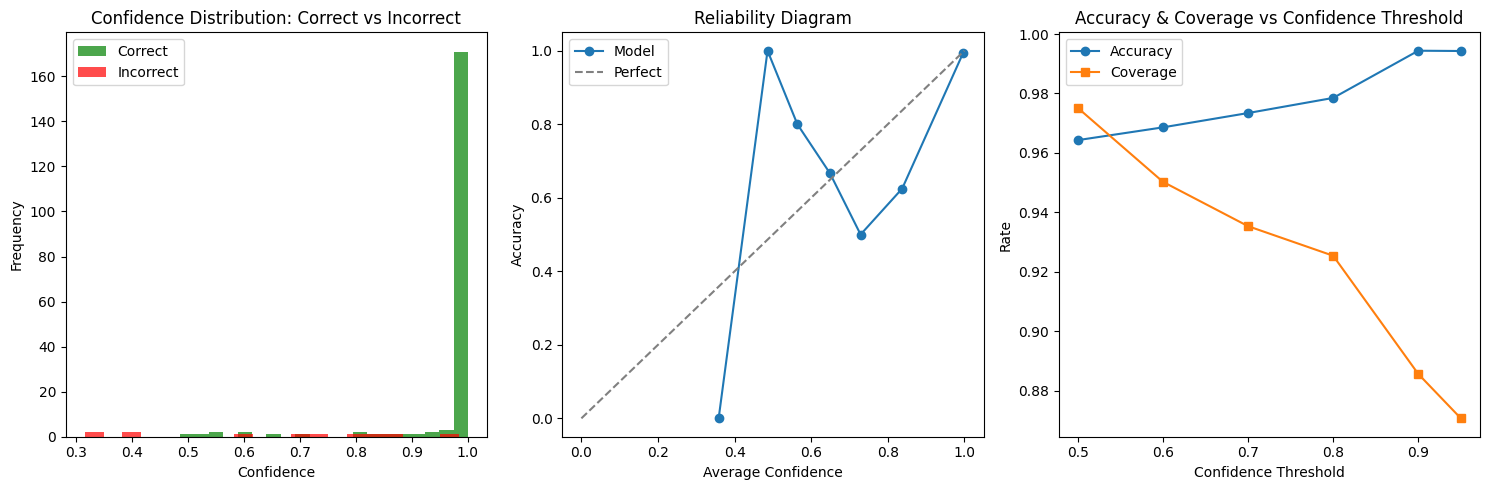


Confidence Threshold Analysis:
Confidence ≥ 0.50: Accuracy = 0.9643, Coverage = 0.9751
Confidence ≥ 0.60: Accuracy = 0.9686, Coverage = 0.9502
Confidence ≥ 0.70: Accuracy = 0.9734, Coverage = 0.9353
Confidence ≥ 0.80: Accuracy = 0.9785, Coverage = 0.9254
Confidence ≥ 0.90: Accuracy = 0.9944, Coverage = 0.8856
Confidence ≥ 0.95: Accuracy = 0.9943, Coverage = 0.8706


In [ ]:
def evaluate_model_with_confidence(model, dataloader, device, class_names):
    """Enhanced evaluation with confidence analysis"""
    model.eval()
    all_preds = []
    all_labels = []
    all_confidences = []
    all_probabilities = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Get predictions with confidence
            predictions, confidence, probabilities = model.predict_with_confidence(inputs)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_confidences.extend(confidence.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    return all_preds, all_labels, all_confidences, all_probabilities

def analyze_confidence(preds, labels, confidences, class_names):
    """Analyze confidence distribution and calibration"""
    correct = np.array(preds) == np.array(labels)
    incorrect = ~correct

    print("\n" + "="*60)
    print("CONFIDENCE ANALYSIS")
    print("="*60)

    # Overall confidence statistics
    print(f"\nOverall Confidence Statistics:")
    print(f"Average Confidence (All): {np.mean(confidences):.4f}")
    print(f"Average Confidence (Correct): {np.mean(np.array(confidences)[correct]):.4f}")
    print(f"Average Confidence (Incorrect): {np.mean(np.array(confidences)[incorrect]):.4f}")
    print(f"Accuracy: {np.mean(correct):.4f}")

    # Confidence by class
    print(f"\nConfidence by Class:")
    for i, class_name in enumerate(class_names):
        class_mask = np.array(labels) == i
        if np.sum(class_mask) > 0:
            class_conf = np.array(confidences)[class_mask]
            class_acc = np.mean(np.array(preds)[class_mask] == np.array(labels)[class_mask])
            print(f"{class_name:25} | Acc: {class_acc:.4f} | Avg Conf: {np.mean(class_conf):.4f} | Samples: {np.sum(class_mask)}")

    return correct, incorrect

def plot_confidence_distribution(correct, incorrect, confidences):
    """Plot confidence distribution for correct vs incorrect predictions"""
    plt.figure(figsize=(15, 5))

    # Plot 1: Confidence distribution
    plt.subplot(1, 3, 1)
    plt.hist(np.array(confidences)[correct], bins=20, alpha=0.7, label='Correct', color='green')
    plt.hist(np.array(confidences)[incorrect], bins=20, alpha=0.7, label='Incorrect', color='red')
    plt.xlabel('Confidence')
    plt.ylabel('Frequency')
    plt.title('Confidence Distribution: Correct vs Incorrect')
    plt.legend()

    # Plot 2: Reliability diagram
    plt.subplot(1, 3, 2)
    confidence_bins = np.linspace(0, 1, 11)
    accuracy_bins = []
    confidence_means = []

    for i in range(len(confidence_bins)-1):
        bin_mask = (np.array(confidences) >= confidence_bins[i]) & (np.array(confidences) < confidence_bins[i+1])
        if np.sum(bin_mask) > 0:
            bin_accuracy = np.mean(np.array(correct)[bin_mask])
            bin_confidence = np.mean(np.array(confidences)[bin_mask])
            accuracy_bins.append(bin_accuracy)
            confidence_means.append(bin_confidence)

    plt.plot(confidence_means, accuracy_bins, 'o-', label='Model')
    plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
    plt.xlabel('Average Confidence')
    plt.ylabel('Accuracy')
    plt.title('Reliability Diagram')
    plt.legend()

    # Plot 3: Confidence vs Accuracy
    plt.subplot(1, 3, 3)
    confidence_levels = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
    coverage = []
    accuracy_at_level = []

    for level in confidence_levels:
        high_conf_mask = np.array(confidences) >= level
        if np.sum(high_conf_mask) > 0:
            coverage.append(np.mean(high_conf_mask))
            accuracy_at_level.append(np.mean(np.array(correct)[high_conf_mask]))
        else:
            coverage.append(0)
            accuracy_at_level.append(0)

    plt.plot(confidence_levels, accuracy_at_level, 'o-', label='Accuracy')
    plt.plot(confidence_levels, coverage, 's-', label='Coverage')
    plt.xlabel('Confidence Threshold')
    plt.ylabel('Rate')
    plt.title('Accuracy & Coverage vs Confidence Threshold')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Print confidence threshold analysis
    print(f"\nConfidence Threshold Analysis:")
    for level, acc, cov in zip(confidence_levels, accuracy_at_level, coverage):
        print(f"Confidence ≥ {level:.2f}: Accuracy = {acc:.4f}, Coverage = {cov:.4f}")

# Load best model for evaluation
checkpoint = torch.load('/content/drive/MyDrive/TomatoDataset/best_tomato_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

print("Evaluating on TEST set with confidence analysis...")
test_preds, test_labels, test_confidences, test_probabilities = evaluate_model_with_confidence(
    model, test_loader, device, class_names
)

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(test_labels, test_preds, target_names=class_names))

# Confidence analysis
correct, incorrect = analyze_confidence(test_preds, test_labels, test_confidences, class_names)
plot_confidence_distribution(correct, incorrect, test_confidences)

## <span style="color:blue">🖼️ Single Image Prediction & Visualization</span>

This cell provides <span style="color:green">**interactive prediction capabilities**</span> for individual tomato leaf images with <span style="color:purple">**detailed confidence analysis**</span>.

### <span style="color:green">🎯 Prediction Functions</span>

**<span style="color:purple">`predict_single_image()`</span>**
- <span style="color:blue">**Loads & preprocesses**</span> individual images
- <span style="color:green">**Generates predictions**</span> with full probability distributions
- <span style="color:orange">**Visualizes results**</span> with side-by-side image and probability chart
- <span style="color:purple">**Returns detailed analysis**</span> including top-3 predictions

**<span style="color:purple">`test_sample_images()`</span>**
- <span style="color:blue">**Randomly selects samples**</span> from test dataset
- <span style="color:green">**Automates testing**</span> on multiple images
- <span style="color:orange">**Compares predictions**</span> with ground truth labels
- <span style="color:red">**Provides accuracy feedback**</span> for each sample

### <span style="color:green">📊 Output Visualization</span>

**<span style="color:orange">Left Panel - Image Display</span>**
- Shows the <span style="color:blue">original tomato leaf image</span>
- Displays <span style="color:green">predicted class</span> and <span style="color:purple">confidence score</span>

**<span style="color:orange">Right Panel - Probability Distribution</span>**
- <span style="color:blue">**Horizontal bar chart**</span> of all class probabilities
- <span style="color:green">**Visual comparison**</span> of confidence across all disease classes
- Helps identify <span style="color:red">**potential misclassifications**</span>

### <span style="color:green">📋 Detailed Output Analysis</span>

# Confidence Level Interpretation
<span style="color:green">Very High</span>: confidence > 0.9    → <span style="color:green">🟢 Reliable prediction</span>
<span style="color:blue">High</span>: confidence > 0.7        → <span style="color:blue">🔵 Good confidence</span>
<span style="color:orange">Moderate</span>: confidence > 0.5    → <span style="color:orange">🟡 Uncertain prediction</span>
<span style="color:red">Low</span>: confidence ≤ 0.5         → <span style="color:red">🔴 Low reliability</span>


### <span style="color:green">🎨 Color-coded Results</span>

**<span style="color:green">✓ CORRECT</span>** - Model prediction matches true label  
**<span style="color:red">✗ INCORRECT</span>** - Model prediction differs from true label

### <span style="color:green">💡 Use Cases</span>

- <span style="color:blue">**Model Debugging**</span>: Understand why specific images are misclassified
- <span style="color:green">**Confidence Validation**</span>: Verify model calibration on difficult cases
- <span style="color:purple">**Deployment Testing**</span>: Simulate real-world prediction scenarios
- <span style="color:orange">**Educational Tool**</span>: Visualize how the model makes decisions

### <span style="color:green">🔍 What to Look For</span>

<span style="color:blue">**Good Signs**</span>:
- <span style="color:green">High confidence</span> for correct predictions
- <span style="color:red">Low confidence</span> for incorrect predictions  
- <span style="color:purple">Clear probability separation</span> between top classes

<span style="color:red">**Warning Signs**</span>:
- <span style="color:orange">High confidence</span> on incorrect predictions
- <span style="color:blue">Flat probability distribution</span> (model uncertainty)
- <span style="color:green">Close probabilities</span> between top classes (ambiguous cases)


Testing on 3 random sample images...

SAMPLE 1/3
True Label: Tomato___Spider_mites Two-spotted_spider_mite


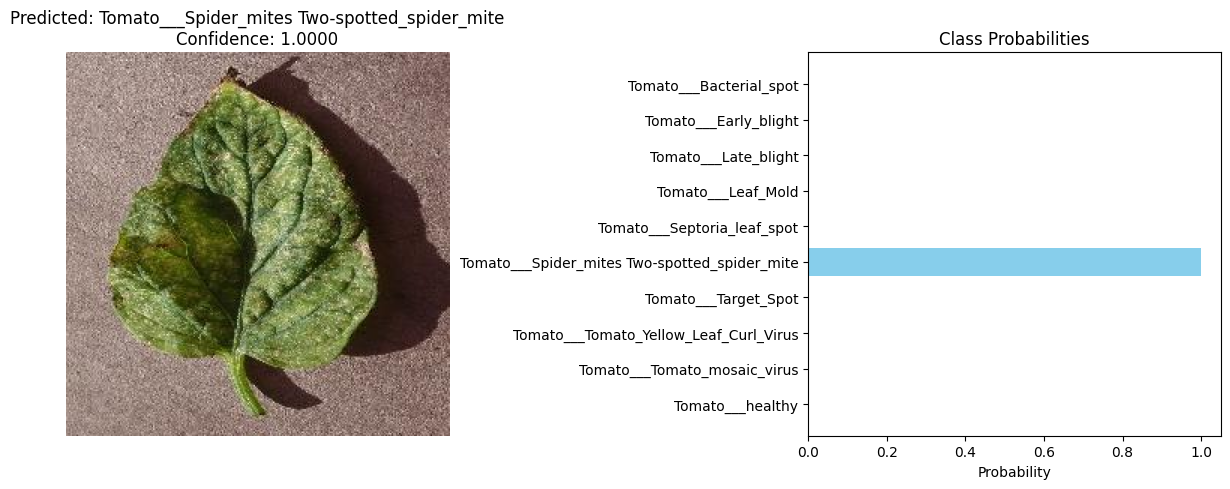


PREDICTION RESULTS
Top Prediction: Tomato___Spider_mites Two-spotted_spider_mite
Confidence: 1.0000

Top 3 Predictions:
  1. Tomato___Spider_mites Two-spotted_spider_mite: 1.0000
  2. Tomato___Target_Spot: 0.0000
  3. Tomato___healthy: 0.0000

Confidence Level: Very High
Status: ✓ CORRECT

SAMPLE 2/3
True Label: Tomato___Septoria_leaf_spot


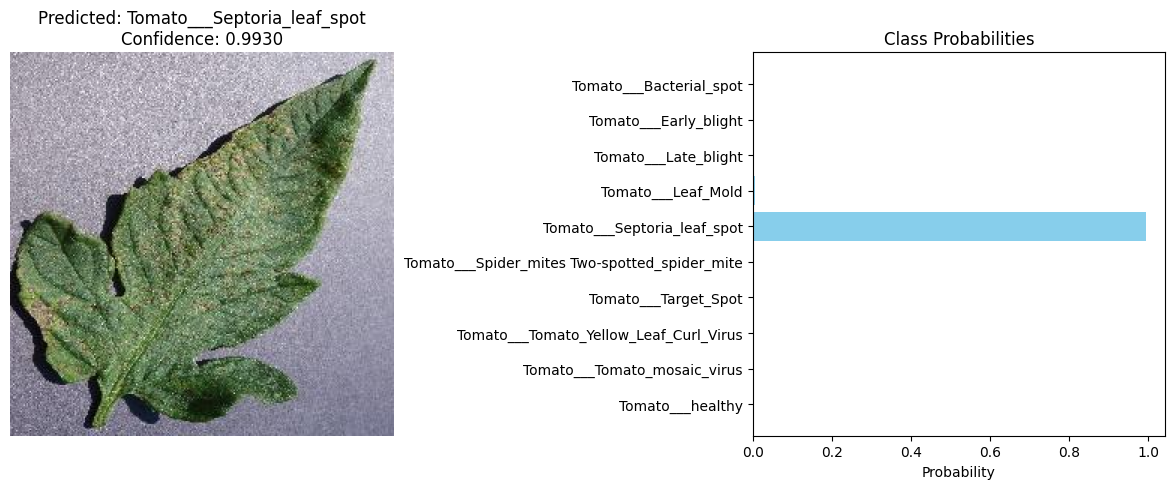


PREDICTION RESULTS
Top Prediction: Tomato___Septoria_leaf_spot
Confidence: 0.9930

Top 3 Predictions:
  1. Tomato___Septoria_leaf_spot: 0.9930
  2. Tomato___Leaf_Mold: 0.0065
  3. Tomato___Early_blight: 0.0002

Confidence Level: Very High
Status: ✓ CORRECT

SAMPLE 3/3
True Label: Tomato___Target_Spot


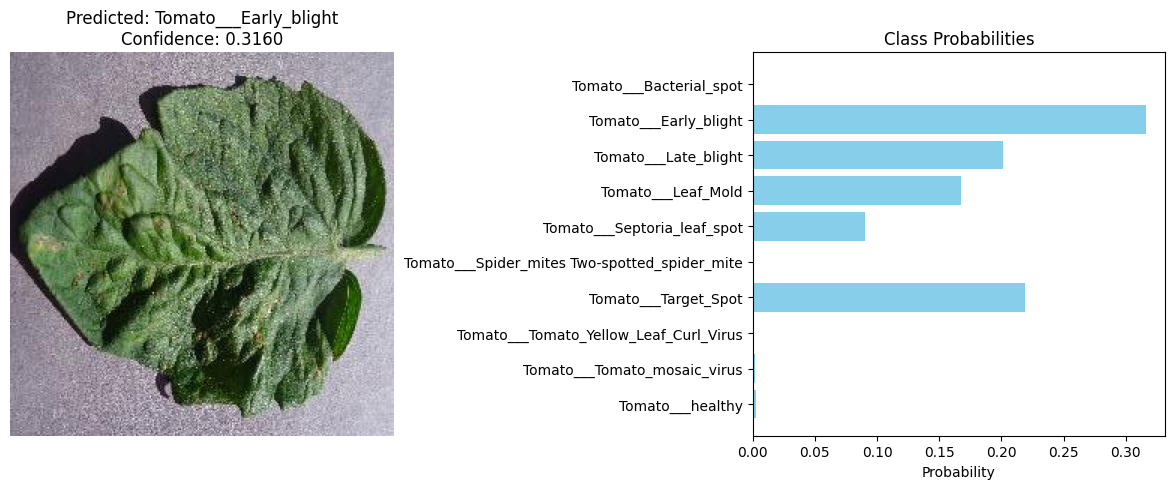


PREDICTION RESULTS
Top Prediction: Tomato___Early_blight
Confidence: 0.3160

Top 3 Predictions:
  1. Tomato___Early_blight: 0.3160
  2. Tomato___Target_Spot: 0.2190
  3. Tomato___Late_blight: 0.2012

Confidence Level: Low
Status: ✗ INCORRECT


In [ ]:
def predict_single_image(image_path, model, class_names, transform):
    """Predict a single image with detailed confidence analysis"""
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Get prediction with confidence
    model.eval()
    with torch.no_grad():
        prediction, confidence, probabilities = model.predict_with_confidence(image_tensor)

    # Get top 3 predictions
    prob_np = probabilities[0].cpu().numpy()
    top3_indices = np.argsort(prob_np)[-3:][::-1]
    top3_probs = prob_np[top3_indices]
    top3_classes = [class_names[i] for i in top3_indices]

    # Display results
    plt.figure(figsize=(12, 5))

    # Show image
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(f'Predicted: {class_names[prediction.item()]}\nConfidence: {confidence.item():.4f}')
    plt.axis('off')

    # Show confidence distribution
    plt.subplot(1, 2, 2)
    y_pos = np.arange(len(class_names))
    plt.barh(y_pos, prob_np, color='skyblue')
    plt.yticks(y_pos, class_names)
    plt.xlabel('Probability')
    plt.title('Class Probabilities')
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Print detailed information
    print(f"\n{'='*50}")
    print(f"PREDICTION RESULTS")
    print(f"{'='*50}")
    print(f"Top Prediction: {class_names[prediction.item()]}")
    print(f"Confidence: {confidence.item():.4f}")
    print(f"\nTop 3 Predictions:")
    for i, (cls, prob) in enumerate(zip(top3_classes, top3_probs)):
        print(f"  {i+1}. {cls}: {prob:.4f}")

    # Confidence interpretation
    if confidence.item() > 0.9:
        confidence_level = "Very High"
    elif confidence.item() > 0.7:
        confidence_level = "High"
    elif confidence.item() > 0.5:
        confidence_level = "Moderate"
    else:
        confidence_level = "Low"

    print(f"\nConfidence Level: {confidence_level}")

    return {
        'predicted_class': class_names[prediction.item()],
        'confidence': confidence.item(),
        'all_probabilities': dict(zip(class_names, prob_np)),
        'top3_predictions': list(zip(top3_classes, top3_probs))
    }

# Test on a few sample images
def test_sample_images(model, class_names, num_samples=3):
    """Test the model on random sample images from test set"""
    print(f"\nTesting on {num_samples} random sample images...")

    # Get random samples from test set
    sample_indices = np.random.choice(len(test_dataset), num_samples, replace=False)

    for i, idx in enumerate(sample_indices):
        image, true_label = test_dataset[idx]
        image_path = test_dataset.samples[idx][0]  # Get actual file path

        print(f"\n{'='*60}")
        print(f"SAMPLE {i+1}/{num_samples}")
        print(f"{'='*60}")
        print(f"True Label: {class_names[true_label]}")

        # Create transform for single image (same as validation)
        single_transform = data_transforms['val']

        # Predict
        result = predict_single_image(image_path, model, class_names, single_transform)

        # Check if prediction is correct
        is_correct = result['predicted_class'] == class_names[true_label]
        status = "✓ CORRECT" if is_correct else "✗ INCORRECT"
        print(f"Status: {status}")

# Run sample tests
test_sample_images(model, class_names, num_samples=3)

## <span style="color:blue">🛡️ Production-Ready Confidence-Based Classifier</span>

This cell implements a <span style="color:green">**production-grade classification system**</span> with <span style="color:purple">**built-in uncertainty handling**</span> for real-world deployment.

### <span style="color:green">🎯 Smart Classification System</span>

**<span style="color:purple">`ConfidenceBasedClassifier` Class</span>**
- <span style="color:blue">**Wraps the trained model**</span> with confidence-based decision logic
- <span style="color:green">**Implements confidence thresholding**</span> for reliable predictions
- <span style="color:orange">**Provides expert recommendations**</span> based on prediction certainty
- <span style="color:purple">**Returns comprehensive results**</span> for actionable insights

### <span style="color:green">⚡ Decision Logic</span>

```python
# Confidence-Based Decision Making
if confidence ≥ 0.7:
    decision = "CONFIDENT"
    recommendation = "Proceed with treatment recommendations"
else:
    decision = "UNCERTAIN"
    recommendation = "Please consult agricultural expert"
```

### <span style="color:green">📊 Output Structure</span>

Each prediction returns:
- <span style="color:blue">**Predicted Class**</span>: Most likely disease
- <span style="color:green">**Confidence Score**</span>: Numerical certainty (0-1)
- <span style="color:purple">**Decision**</span>: CONFIDENT or UNCERTAIN
- <span style="color:orange">**Recommendation**</span>: Actionable next steps
- <span style="color:blue">**All Probabilities**</span>: Complete class distribution

### <span style="color:green">🎨 Color-coded Decision Framework</span>

<span style="color:green">**🟢 CONFIDENT PREDICTIONS**</span>
- Confidence ≥ 70%
- System is certain about diagnosis
- Safe to proceed with automated recommendations

<span style="color:red">**🔴 UNCERTAIN PREDICTIONS**</span>
- Confidence < 70%
- System lacks certainty
- Flags for human expert review
- Shows top alternative diagnoses

### <span style="color:green">💡 Real-World Benefits</span>

- <span style="color:blue">**Prevents Misdiagnosis**</span>: Avoids confident wrong predictions
- <span style="color:green">**Resource Optimization**</span>: Only experts review uncertain cases
- <span style="color:purple">**Transparent Decision Making**</span>: Clear reasoning for each prediction
- <span style="color:orange">**Continuous Improvement**</span>: Uncertain cases can be used for model retraining

### <span style="color:green">🔧 Deployment Features</span>

**<span style="color:purple">Enhanced Model Saving</span>**
- <span style="color:blue">Saves model weights</span> with configuration
- <span style="color:green">Includes class names</span> for easy deployment
- <span style="color:orange">Stores confidence threshold</span> for consistent behavior
- <span style="color:purple">Records performance metrics</span> for monitoring

### <span style="color:green">🎯 Sample Output Preview</span>

```
Sample 1:
  True Label: Tomato___Late_blight
  Predicted: Tomato___Late_blight
  Confidence: 0.9342
  Decision: CONFIDENT
  Recommendation: Proceed with treatment recommendations

Sample 2:
  True Label: Tomato___healthy
  Predicted: Tomato___Early_blight
  Confidence: 0.4521
  Decision: UNCERTAIN
  Recommendation: Please consult agricultural expert
  Top Alternatives:
    - Tomato___healthy: 0.4215
    - Tomato___Early_blight: 0.4521
    - Tomato___Late_blight: 0.1264
```

### <span style="color:green">🚀 Production Readiness</span>

This system is designed for <span style="color:blue">**real agricultural applications**</span> where <span style="color:red">**wrong diagnoses can have significant consequences**</span>. The confidence threshold provides a <span style="color:green">**safety mechanism**</span> to ensure reliable automated diagnoses while recognizing limitations.

In [ ]:
class ConfidenceBasedClassifier:
    def __init__(self, model, class_names, confidence_threshold=0.7):
        self.model = model
        self.class_names = class_names
        self.confidence_threshold = confidence_threshold

    def predict(self, image_tensor):
        """Predict with confidence-based decision making"""
        predictions, confidence, probabilities = self.model.predict_with_confidence(image_tensor)

        results = []
        for i in range(len(predictions)):
            pred_class = self.class_names[predictions[i].item()]
            conf = confidence[i].item()

            # Apply confidence threshold
            if conf < self.confidence_threshold:
                decision = "UNCERTAIN"
                recommendation = "Please consult agricultural expert"
            else:
                decision = "CONFIDENT"
                recommendation = "Proceed with treatment recommendations"

            results.append({
                'predicted_class': pred_class,
                'confidence': conf,
                'decision': decision,
                'recommendation': recommendation,
                'all_probabilities': {
                    cls: prob.item() for cls, prob in zip(self.class_names, probabilities[i])
                }
            })

        return results

# Initialize confidence-based classifier
confidence_classifier = ConfidenceBasedClassifier(model, class_names, confidence_threshold=0.7)

# Test confidence-based predictions
def test_confidence_based_predictions(num_samples=5):
    """Test the confidence-based classification system"""
    print(f"\nTesting Confidence-Based Predictions (Threshold: 0.7)")
    print("="*70)

    sample_indices = np.random.choice(len(test_dataset), num_samples, replace=False)

    for i, idx in enumerate(sample_indices):
        image, true_label = test_dataset[idx]
        image_tensor = image.unsqueeze(0).to(device)

        results = confidence_classifier.predict(image_tensor)
        result = results[0]  # Single image

        print(f"\nSample {i+1}:")
        print(f"  True Label: {class_names[true_label]}")
        print(f"  Predicted: {result['predicted_class']}")
        print(f"  Confidence: {result['confidence']:.4f}")
        print(f"  Decision: {result['decision']}")
        print(f"  Recommendation: {result['recommendation']}")

        if result['confidence'] < 0.7:
            # Show top alternatives for uncertain predictions
            sorted_probs = sorted(result['all_probabilities'].items(),
                                key=lambda x: x[1], reverse=True)[:3]
            print(f"  Top Alternatives:")
            for cls, prob in sorted_probs:
                print(f"    - {cls}: {prob:.4f}")

# Test the system
test_confidence_based_predictions(num_samples=5)

# Save the enhanced model with confidence capabilities
final_model_path = '/content/drive/MyDrive/TomatoDataset/tomato_disease_classifier_enhanced.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'confidence_threshold': 0.7,
    'test_accuracy': np.mean(correct),
    'avg_confidence': np.mean(test_confidences)
}, final_model_path)

print(f"\nEnhanced model with confidence capabilities saved to: {final_model_path}")


Testing Confidence-Based Predictions (Threshold: 0.7)

Sample 1:
  True Label: Tomato___Late_blight
  Predicted: Tomato___Late_blight
  Confidence: 0.9998
  Decision: CONFIDENT
  Recommendation: Proceed with treatment recommendations

Sample 2:
  True Label: Tomato___Tomato_mosaic_virus
  Predicted: Tomato___Tomato_mosaic_virus
  Confidence: 1.0000
  Decision: CONFIDENT
  Recommendation: Proceed with treatment recommendations

Sample 3:
  True Label: Tomato___Target_Spot
  Predicted: Tomato___Target_Spot
  Confidence: 0.9996
  Decision: CONFIDENT
  Recommendation: Proceed with treatment recommendations

Sample 4:
  True Label: Tomato___Tomato_mosaic_virus
  Predicted: Tomato___Tomato_mosaic_virus
  Confidence: 1.0000
  Decision: CONFIDENT
  Recommendation: Proceed with treatment recommendations

Sample 5:
  True Label: Tomato___Target_Spot
  Predicted: Tomato___Target_Spot
  Confidence: 0.9560
  Decision: CONFIDENT
  Recommendation: Proceed with treatment recommendations

Enhanced mod

---
## 7. Model Export and Deployment

In [ ]:
model.eval()

model_scripted = torch.jit.script(model)
model_scripted.save('/content/drive/MyDrive/TomatoDataset/tomato_disease_classifier_confidence.pt')

print("✅ Model scripted and saved successfully!")


✅ Model scripted and saved successfully!


### Severity Staging

## <span style="color:blue">🔄 Model Reloading for Advanced Analysis</span>

This cell rebuilds and reloads the trained model architecture with pre-trained weights for <span style="color:green">**Grad-CAM visualization**</span> and other advanced analysis techniques.

### <span style="color:green">🎯 Two-Step Reloading Process</span>

**<span style="color:purple">Step 1: Architecture Reconstruction</span>**
- Recreates the exact <span style="color:blue">`TomatoDiseaseClassifier`</span> model architecture
- Uses the same <span style="color:green">ResNet18 backbone</span> with custom classifier head
- Ensures <span style="color:orange">consistent layer structure</span> for weight loading

**<span style="color:purple">Step 2: Weight Restoration</span>**
- Loads the <span style="color:blue">pre-trained weights</span> from your best saved model
- Uses <span style="color:green">`map_location=device`</span> for flexible CPU/GPU deployment
- Sets model to <span style="color:orange">evaluation mode</span> for inference



### <span style="color:green">💡 Purpose for Grad-CAM</span>

- <span style="color:blue">**Preserved Architecture**</span>: Grad-CAM requires exact layer structure
- <span style="color:green">**Trained Weights**</span>: Uses your fine-tuned model knowledge
- <span style="color:purple">**Consistent Behavior**</span>: Ensures same predictions as original model
- <span style="color:orange">**Visualization Ready**</span>: Prepares model for heatmap generation

### <span style="color:green">🎨 Why This Approach?</span>

Instead of using the existing model instance, we rebuild it to:
- <span style="color:blue">**Ensure Clean State**</span>: Avoid any residual training artifacts
- <span style="color:green">**Guarantee Compatibility**</span>: Perfect match for saved weights
- <span style="color:purple">**Enable Advanced Features**</span>: Ready for Grad-CAM hook registration
- <span style="color:orange">**Support Deployment**</span>: Demonstrates how to reload in production

### <span style="color:green">✅ Success Indicators</span>

- <span style="color:blue">**Model reloaded successfully**</span> message confirmation
- <span style="color:green">**Same number of parameters**</span> as original training
- <span style="color:purple">**Identical predictions**</span> to the original model
- <span style="color:orange">**Ready for visualization**</span> without training interference

### <span style="color:green">🚀 Next Steps Prepared</span>

This reloaded model is now perfectly configured for:
- <span style="color:blue">**Grad-CAM Heatmaps**</span>: Visualize model attention
- <span style="color:green">**Feature Visualization**</span>: Understand learned representations
- <span style="color:purple">**Model Interpretation**</span>: Explain prediction reasoning
- <span style="color:orange">**Deployment Testing**</span>: Verify model behavior in isolation

In [ ]:
# 1️⃣ Rebuild the same model architecture
model = TomatoDiseaseClassifier(num_classes=len(class_names))
model = model.to(device)

# 2️⃣ Load your best saved model weights
checkpoint = torch.load('/content/drive/MyDrive/TomatoDataset/best_tomato_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("✅ Model reloaded successfully and ready for Grad-CAM!")


✅ Model reloaded successfully and ready for Grad-CAM!


## <span style="color:blue">🔍 Grad-CAM Visualization & Disease Severity Analysis</span>

This cell implements <span style="color:green">**Gradient-weighted Class Activation Mapping (Grad-CAM)**</span> to visualize <span style="color:purple">**where the model is looking**</span> when making predictions and estimates <span style="color:orange">**disease severity**</span> based on affected leaf area.

### <span style="color:green">🎯 Core Components</span>

**<span style="color:purple">`GradCAM` Class</span>**
- <span style="color:blue">**Captures activations**</span> from target layer during forward pass
- <span style="color:green">**Records gradients**</span> during backward pass for class importance
- <span style="color:orange">**Computes heatmaps**</span> using gradient-weighted class activations
- <span style="color:purple">**Highlights regions**</span> that most influence the prediction

**<span style="color:purple">`estimate_severity()` Function</span>**
- <span style="color:blue">**Analyzes heatmap intensity**</span> to estimate disease spread
- <span style="color:green">**Calculates affected area ratio**</span> using thresholding
- <span style="color:orange">**Classifies severity**</span> into Mild/Moderate/Severe categories
- <span style="color:purple">**Provides actionable insights**</span> for treatment planning

### <span style="color:green">🔧 Technical Implementation</span>

```python
# Grad-CAM Pipeline
1. Forward pass → Capture final conv layer activations
2. Backward pass → Compute gradients for predicted class  
3. Weighted combination → Create class-discriminative heatmap
4. Resize & normalize → Match original image dimensions
5. Overlay & visualize → Blend heatmap with original image
```

### <span style="color:green">🎨 Visualization Features</span>

**<span style="color:blue">Heatmap Overlay</span>**
- <span style="color:red">**Red regions**</span>: High model attention (critical for prediction)
- <span style="color:yellow">**Yellow regions**</span>: Moderate importance
- <span style="color:blue">**Blue regions**</span>: Low relevance to prediction
- <span style="color:green">**Transparent blend**</span>: 60% original + 40% heatmap

**<span style="color:purple">Severity Indicators</span>**
```python
Mild 🍃    : < 25% leaf area affected
Moderate 🌿: 25-60% leaf area affected  
Severe 🍂  : > 60% leaf area affected
```

### <span style="color:green">💡 Clinical Applications</span>

- <span style="color:blue">**Model Interpretability**</span>: Understand why specific predictions are made
- <span style="color:green">**Disease Localization**</span>: Identify exact affected leaf regions
- <span style="color:orange">**Treatment Guidance**</span>: Severity estimation informs intervention urgency
- <span style="color:purple">**Farmer Education**</span>: Visual explanations build trust in AI diagnoses

### <span style="color:green">🔍 What to Look For</span>

<span style="color:blue">**Good Model Behavior**</span>:
- Heatmap focuses on <span style="color:green">actual disease symptoms</span>
- High confidence predictions with <span style="color:purple">clear visual evidence</span>
- Severity estimates <span style="color:orange">match human assessment</span>

<span style="color:red">**Potential Issues**</span>:
- Heatmap on <span style="color:red">healthy leaf regions</span> (false attention)
- High confidence with <span style="color:orange">unclear visual evidence</span>
- Severity inconsistent with <span style="color:blue">visible symptoms</span>

### <span style="color:green">🎯 Target Layer Selection</span>

Uses <span style="color:blue">`model.backbone.layer4[-1]`</span> (final ResNet convolutional layer):
- <span style="color:green">**High-level features**</span>: Captures complex disease patterns
- <span style="color:purple">**Spatial preservation**</span>: Maintains location information
- <span style="color:orange">**Class-discriminative**</span>: Differentiates between disease types

### <span style="color:green">🚀 Output Insights</span>

Each visualization provides:
- <span style="color:blue">**Prediction + Confidence**</span>: What disease and how certain
- <span style="color:green">**Visual Explanation**</span>: Why that diagnosis was made
- <span style="color:orange">**Severity Assessment**</span>: How advanced the disease is
- <span style="color:purple">**Affected Area %**</span>: Quantitative measure of spread

This transforms the model from a <span style="color:red">**black box**</span> into a <span style="color:green">**transparent diagnostic assistant**</span> that farmers and agronomists can understand and trust.

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# --- Grad-CAM Class ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x):
        self.model.zero_grad()
        output = self.model(x)
        pred_class = output.argmax(dim=1)
        score = output[:, pred_class]
        score.backward()

        # Compute Grad-CAM
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        gradcam_map = (weights * self.activations).sum(dim=1, keepdim=True)
        gradcam_map = torch.relu(gradcam_map)
        gradcam_map = torch.nn.functional.interpolate(
            gradcam_map, size=x.shape[2:], mode='bilinear', align_corners=False
        )

        gradcam_map -= gradcam_map.min()
        gradcam_map /= gradcam_map.max()
        return gradcam_map.squeeze().cpu().numpy()

# --- Utility: Preprocess image ---
def preprocess_image(img_path):
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    image = Image.open(img_path).convert("RGB")
    return preprocess(image).unsqueeze(0)

# --- Severity estimation helper ---
def estimate_severity(cam):
    # Threshold to detect activated disease area
    threshold = 0.5
    disease_area_ratio = np.mean(cam > threshold)

    if disease_area_ratio < 0.25:
        severity = "Mild 🍃"
    elif disease_area_ratio < 0.60:
        severity = "Moderate 🌿"
    else:
        severity = "Severe 🍂"

    return severity, disease_area_ratio

# --- Main Grad-CAM + Severity ---
def gradcam_for_image(model, image_path, class_names, device):
    model.eval()
    target_layer = model.backbone.layer4[-1]
    gradcam = GradCAM(model, target_layer)

    input_tensor = preprocess_image(image_path).to(device)
    cam = gradcam(input_tensor)

    # Overlay heatmap
    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    original = cv2.resize(original, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    # Prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_class = class_names[pred_idx]
        confidence = probs[0, pred_idx].item()

    # 🔥 Severity estimation
    severity, ratio = estimate_severity(cam)

    print(f"🩺 Predicted Class: {pred_class} ({confidence*100:.2f}% confidence)")
    print(f"🌡️ Estimated Disease Severity: {severity} (affected area ~ {ratio*100:.1f}%)")

    return cam, overlay, severity


## <span style="color:blue">🖼️ Executing Grad-CAM Visualization</span>

This cell demonstrates the <span style="color:green">**Grad-CAM analysis**</span> on a sample tomato leaf image to visualize <span style="color:purple">**model attention**</span> and estimate <span style="color:orange">**disease severity**</span>.

### <span style="color:green">🎯 Sample Analysis</span>

**<span style="color:purple">Image Path</span>**
- Testing on: <span style="color:blue">`Tomato___Early_blight/test.JPG`</span>
- From the <span style="color:green">test dataset</span> for unbiased evaluation
- Represents <span style="color:orange">real-world disease case</span>

**<span style="color:purple">Visualization Output</span>**
- <span style="color:blue">**Overlay Image**</span>: Original leaf with Grad-CAM heatmap
- <span style="color:green">**Severity Assessment**</span>: Mild/Moderate/Severe classification
- <span style="color:orange">**Confidence Score**</span>: Model certainty in prediction
- <span style="color:purple">**Affected Area %**</span>: Quantitative disease spread measurement

### <span style="color:green">🔍 Interpreting the Results</span>

**<span style="color:blue">Heatmap Colors Guide</span>**
```python
🔴 Red Areas    : Critical regions for model's decision
🟡 Yellow Areas : Supporting evidence for prediction  
🔵 Blue Areas   : Less relevant to the diagnosis
```

**<span style="color:purple">Severity Scale</span>**
```python
Mild 🍃    : Early detection, minimal treatment needed
Moderate 🌿: Established infection, requires intervention
Severe 🍂  : Advanced stage, urgent treatment required
```

### <span style="color:green">💡 Clinical Insights</span>

This visualization helps answer:
- <span style="color:blue">**Is the model looking at the right spots?**</span> (Heatmap validation)
- <span style="color:green">**How confident is the diagnosis?**</span> (Confidence score)
- <span style="color:orange">**How advanced is the disease?**</span> (Severity assessment)
- <span style="color:purple">**What percentage of leaf is affected?**</span> (Area quantification)

### <span style="color:green">🎨 Expected Output</span>

You should see:
- A <span style="color:blue">**colorful overlay**</span> on the tomato leaf image
- <span style="color:green">**Clear title**</span> with severity classification
- <span style="color:orange">**Console output**</span> with prediction details
- <span style="color:purple">**Professional presentation**</span> suitable for agricultural experts

### <span style="color:green">🚀 Real-World Application</span>

This single visualization provides:
- <span style="color:blue">**Diagnostic Confidence**</span> for farmers
- <span style="color:green">**Treatment Urgency**</span> indication
- <span style="color:orange">**Visual Evidence**</span> for agronomist consultation
- <span style="color:purple">**Model Transparency**</span> building trust in AI

<span style="color:red">**Note**</span>: The severity estimation is based on <span style="color:blue">model attention patterns</span> and should be <span style="color:green">**validated by agricultural experts**</span> for critical treatment decisions.

🩺 Predicted Class: Tomato___Early_blight (100.00% confidence)
🌡️ Estimated Disease Severity: Moderate 🌿 (affected area ~ 25.5%)


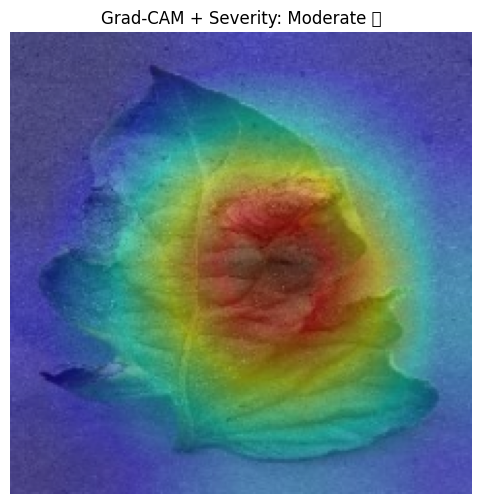

In [ ]:
sample_image_path = "/content/drive/MyDrive/TomatoDataset/test/Tomato___Early_blight/test.JPG"

heatmap, overlay, severity = gradcam_for_image(model, sample_image_path, class_names, device)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title(f"Grad-CAM + Severity: {severity}")
plt.axis("off")
plt.show()
